In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
from pyRheo.oscillation_model import OscillationModel
import scienceplots
plt.style.use(['science', 'nature', 'bright'])

# Filenames for heating and cooling
heating_files = [
    #'../data/processed/mc_1.75/heating/mc_1.75_heating_FS_10.csv', # Measurement failed
    '../data/processed/mc_1.75/heating/mc_1.75_heating_FS_15.csv',
    '../data/processed/mc_1.75/heating/mc_1.75_heating_FS_20.csv',
    '../data/processed/mc_1.75/heating/mc_1.75_heating_FS_25.csv',
    '../data/processed/mc_1.75/heating/mc_1.75_heating_FS_30.csv',
    '../data/processed/mc_1.75/heating/mc_1.75_heating_FS_35.csv',
    #../data/processed/'mc_1.75/heating/mc_1.75_heating_FS_40.csv',
    '../data/processed/mc_1.75/heating/mc_1.75_heating_FS_45.csv',
    '../data/processed/mc_1.75/heating/mc_1.75_heating_FS_50.csv',
    '../data/processed/mc_1.75/heating/mc_1.75_heating_FS_55.csv',
    '../data/processed/mc_1.75/heating/mc_1.75_heating_FS_60.csv',
    '../data/processed/mc_1.75/heating/mc_1.75_heating_FS_65.csv',
    '../data/processed/mc_1.75/heating/mc_1.75_heating_FS_70.csv',
    '../data/processed/mc_1.75/heating/mc_1.75_heating_FS_75.csv',
    '../data/processed/mc_1.75/heating/mc_1.75_heating_FS_80.csv'
]
cooling_files = [
    #'../data/processed/mc_1.75/cooling/mc_1.75_cooling_FS_10.csv', # Measurement failed
    '../data/processed/mc_1.75/cooling/mc_1.75_cooling_FS_15.csv',
    '../data/processed/mc_1.75/cooling/mc_1.75_cooling_FS_20.csv',
    '../data/processed/mc_1.75/cooling/mc_1.75_cooling_FS_25.csv',
    '../data/processed/mc_1.75/cooling/mc_1.75_cooling_FS_30.csv',
    '../data/processed/mc_1.75/cooling/mc_1.75_cooling_FS_35.csv',
    '../data/processed/mc_1.75/cooling/mc_1.75_cooling_FS_40.csv',
    '../data/processed/mc_1.75/cooling/mc_1.75_cooling_FS_45.csv',
    '../data/processed/mc_1.75/cooling/mc_1.75_cooling_FS_50.csv',
    '../data/processed/mc_1.75/cooling/mc_1.75_cooling_FS_55.csv',
    '../data/processed/mc_1.75/cooling/mc_1.75_cooling_FS_60.csv',
    '../data/processed/mc_1.75/cooling/mc_1.75_cooling_FS_65.csv',
    '../data/processed/mc_1.75/cooling/mc_1.75_cooling_FS_70.csv',
    '../data/processed/mc_1.75/cooling/mc_1.75_cooling_FS_75.csv'
]

columns = [
    'Point No.', 'Time', 'Test Time', 'Temperature', 'Angular Frequency', 
    'Storage Modulus', 'Loss Modulus', 'Loss Factor', 'Shear Stress', 'Shear Strain', 'Torque'
]

# Initialize lists for all data
omega_log_list = []
G_prime_log_list = []
G_double_prime_log_list = []
tan_delta_log_list = []
G_complex_log_list = []
t_log_list = []
temp_list = []
process_list = []  # Track heating or cooling

# Function to process files and append data to lists
def process_files(file_list, process_type):
    for filename in file_list:
        data = pd.read_csv(filename, skiprows=[1], delimiter=',', decimal=".", encoding='utf-8')
        data.columns = columns

        # Filter the data where Angular Frequency is smaller than 0.5
        filtered_data = data[data['Angular Frequency'] < 10]

        # Only proceed if there is data after filtering
        if filtered_data.empty:
            print(f"Warning: No data in filtered range for filename {filename}")
            continue

        match = re.search(r'_(\d+)\.csv', filename)
        if match:
            temp = float(match.group(1))
        else:
            print(f"Warning: No temperature found in filename {filename}")
            continue

        # Compute logarithms of filtered data
        log_omega = np.log(filtered_data['Angular Frequency'])
        log_Gp = np.log(filtered_data['Storage Modulus'])
        log_Gpp = np.log(filtered_data['Loss Modulus'])
        log_tan_delta = log_Gpp - log_Gp
        log_G_complex = np.log(np.sqrt(filtered_data['Storage Modulus']**2 + filtered_data['Loss Modulus']**2))
        log_t = np.log(filtered_data['Time'])

        # Append to lists
        omega_log_list.append(np.array(log_omega))
        G_prime_log_list.append(np.array(log_Gp))
        G_double_prime_log_list.append(np.array(log_Gpp))
        tan_delta_log_list.append(np.array(log_tan_delta))
        G_complex_log_list.append(np.array(log_G_complex))
        t_log_list.append(np.array(log_t))
        temp_list.append(temp)
        process_list.append(process_type)

# Process heating and cooling files with the filter applied
process_files(heating_files, "heating")
process_files(cooling_files, "cooling")

print("Data processed successfully and sorted into lists")

Data processed successfully and sorted into lists


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


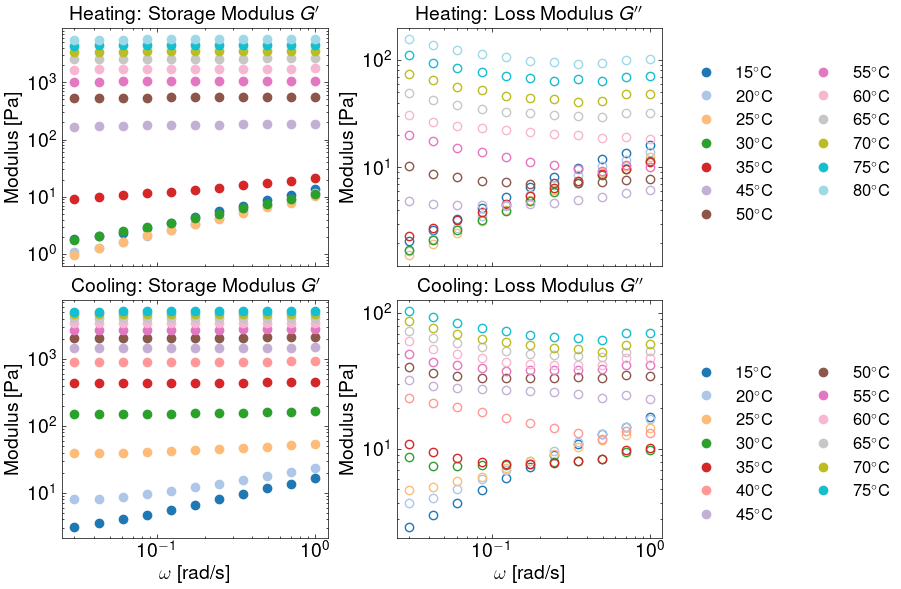

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Labels for temperatures (assumed same for heating and cooling)
labels = [
    #"10$^{\circ}$C", 
    "15$^{\circ}$C", "20$^{\circ}$C", "25$^{\circ}$C", "30$^{\circ}$C",
    "35$^{\circ}$C", "40$^{\circ}$C", "45$^{\circ}$C", "50$^{\circ}$C", "55$^{\circ}$C",
    "60$^{\circ}$C", "65$^{\circ}$C", "70$^{\circ}$C", "75$^{\circ}$C", "80$^{\circ}$C"
]

# Separate indices for heating and cooling data
heating_indices = [i for i, p in enumerate(process_list) if p == 'heating']
cooling_indices = [i for i, p in enumerate(process_list) if p == 'cooling']

# Colors (same palette for both)
colors = plt.cm.tab20(np.linspace(0, 1, len(labels)))

fig, axes = plt.subplots(2, 2, figsize=(8, 6), sharex=True)

# Heating plots
ax1, ax2 = axes[0]
ax1.set_title("Heating: Storage Modulus $G'$", fontsize=14)
ax2.set_title("Heating: Loss Modulus $G''$", fontsize=14)

for i in heating_indices:
    omega = np.exp(omega_log_list[i])
    G_prime = np.exp(G_prime_log_list[i])
    G_double_prime = np.exp(G_double_prime_log_list[i])
    
    temp = temp_list[i]
    # Find label index (assuming temp matches label temps)
    try:
        label_idx = [int(s.split('$')[0]) for s in labels].index(int(temp))
        label = labels[label_idx]
        color = colors[label_idx]
    except ValueError:
        label = f"{temp}°C"
        color = 'black'
    
    ax1.loglog(omega, G_prime, 'o', label=label, markersize=6, color=color)
    ax2.loglog(omega, G_double_prime, 'o', fillstyle="none", markersize=6, color=color)

ax1.set_ylabel('Modulus [Pa]', fontsize=14)
ax2.set_ylabel('Modulus [Pa]', fontsize=14)

# Cooling plots
ax3, ax4 = axes[1]
ax3.set_title("Cooling: Storage Modulus $G'$", fontsize=14)
ax4.set_title("Cooling: Loss Modulus $G''$", fontsize=14)

for i in cooling_indices:
    omega = np.exp(omega_log_list[i])
    G_prime = np.exp(G_prime_log_list[i])
    G_double_prime = np.exp(G_double_prime_log_list[i])
    
    temp = temp_list[i]
    try:
        label_idx = [int(s.split('$')[0]) for s in labels].index(int(temp))
        label = labels[label_idx]
        color = colors[label_idx]
    except ValueError:
        label = f"{temp}°C"
        color = 'black'
    
    ax3.loglog(omega, G_prime, 'o', label=label, markersize=6, color=color)
    ax4.loglog(omega, G_double_prime, 'o', fillstyle="none", markersize=6, color=color)

ax3.set_xlabel(r'$\omega$ [rad/s]', fontsize=14)
ax4.set_xlabel(r'$\omega$ [rad/s]', fontsize=14)
ax3.set_ylabel('Modulus [Pa]', fontsize=14)
ax4.set_ylabel('Modulus [Pa]', fontsize=14)

for ax in axes.flatten():
    ax.tick_params(axis='both', labelsize=14)
    ax.grid(False)
    ax.legend().remove()

# Shared legends for heating and cooling on right side
handles_h, labels_h = axes[0, 0].get_legend_handles_labels()
handles_c, labels_c = axes[1, 0].get_legend_handles_labels()

fig.legend(handles_h, labels_h, loc='center left', bbox_to_anchor=(0.85, 0.75), ncols=2, fontsize=12)
fig.legend(handles_c, labels_c, loc='center left', bbox_to_anchor=(0.85, 0.25), ncols=2,  fontsize=12)

fig.tight_layout(rect=[0, 0, 0.85, 1])  # leave space for legends
plt.show()

In [3]:
# Let fit the models
assert len(temp_list) == len(omega_log_list), "Mismatch: temperature list and data lists"

# Labels and colors per temperature
labels = [f"{int(t)}°C" for t in temp_list]
color_map = plt.cm.tab20(np.linspace(0, 1, len(labels)))

fitted_parameters_heating = {}
fitted_parameters_cooling = {}

# Store all processed entries in a list for flexible plotting later
entries = []

# 1) Fit models and collect predictions (keeps your model selection/logic)
for i in range(len(omega_log_list)):
    omega_log = omega_log_list[i]
    G_prime_log = G_prime_log_list[i]
    G_double_prime_log = G_double_prime_log_list[i]

    # Back to linear scale (consistent with your code)
    omega = np.exp(omega_log)
    G_prime = np.exp(G_prime_log)
    G_double_prime = np.exp(G_double_prime_log)

    # Filter valid data points
    mask = np.isfinite(omega) & np.isfinite(G_prime) & np.isfinite(G_double_prime) & (omega > 0) & (G_prime > 0) & (G_double_prime > 0)
    omega_filtered = omega[mask]
    Gp_filtered = G_prime[mask]
    Gpp_filtered = G_double_prime[mask]

    # --- Model selection (your rules) ---
    if process_list[i] == 'heating':
        model_name = "SpringPot" if temp_list[i] > 40 else "FractionalKelvinVoigtS"
    elif process_list[i] == 'cooling':
        model_name = "SpringPot" if temp_list[i] > 25 else "FractionalKelvinVoigtS"
    else:
        model_name = "SpringPot"  # fallback

    # --- Set bounds depending on model and conditions ---
    if model_name == "FractionalKelvinVoigtS":
        # special case: heating at exactly 25°C
        if process_list[i] == 'heating' and temp_list[i] == 90: # ignore
            bounds = [(0.65, 1), (8, 10), (0,1)]
        else:
            bounds = "auto"
    else:
        bounds = "auto"

    # --- Define model instance ---
    model = OscillationModel(
        model=model_name,
        initial_guesses="random",
        num_initial_guesses=128,
        minimization_algorithm="Powell",
        cost_function="RSS",
        bounds=bounds,
    )
    model.fit(omega_filtered, Gp_filtered, Gpp_filtered)

    # Debug print
    print(f"\n--- Parameters at {temp_list[i]}°C ({process_list[i]}) ---")
    model.print_parameters()

    fitted_params = model.get_parameters()

    # Safely attach error info
    try:
        err = model.print_error()  # could be a float, dict, or array depending on your implementation
    except Exception:
        err = None

    # Make a copy so we don't mutate internal objects
    params_with_error = dict(fitted_params)

    # Store errors in a predictable way
    if isinstance(err, dict):
        # prefix keys to avoid collisions
        for k, v in err.items():
            params_with_error[f"Error_{k}"] = v
    else:
        # store as a single value
        params_with_error["Error"] = err

    # Store by process
    if process_list[i] == 'heating':
        fitted_parameters_heating[temp_list[i]] = params_with_error
    else:
        fitted_parameters_cooling[temp_list[i]] = params_with_error

    # Prediction range
    omega_predict = np.logspace(np.log10(omega_filtered).min() - 0.5, np.log10(omega_filtered).max() + 0.5, 150)
    Gp_pred, Gpp_pred = model.predict(omega_predict)

    entries.append({
        'idx': i,
        'T': temp_list[i],
        'process': process_list[i],
        'label': f"{int(temp_list[i])}°C",
        'color': color_map[i],
        'omega': omega_filtered,
        'Gp': Gp_filtered,
        'Gpp': Gpp_filtered,
        'omega_pred': omega_predict,
        'Gp_pred': Gp_pred,
        'Gpp_pred': Gpp_pred
    })

/tmp/ipykernel_41261/2667883701.py:50: DeprecationWarning: OscillationModel will be deprecated and will be removed in future versions. Please use SAOSModel instead.
  model = OscillationModel(


Iterations used: 11
Iterations used: 8
Best initial guess was: [2074.6378990074204, 4458.575069741424, 0.4269477345795213]

--- Parameters at 15.0°C (heating) ---
G_p: 0.08550490683026009
V: 21.939928237725926
alpha: 0.6005651296540978
Cost (RSS): 0.05548516367230422
Mean Percentage Error: 4.32%
Cost (RSS): 0.05548516367230422
Iterations used: 5
Iterations used: 9
Iterations used: 9
Best initial guess was: [949.5864685577978, 8832.71220689491, 0.7072128706227879]

--- Parameters at 20.0°C (heating) ---
G_p: 0.0016856345494873789
V: 19.06556733978818
alpha: 0.6372728254022954
Cost (RSS): 0.08224071136689098
Mean Percentage Error: 4.99%
Cost (RSS): 0.08224071136689098
Iterations used: 5
Iterations used: 6
Iterations used: 6
Iterations used: 6
Iterations used: 12
Iterations used: 14
Iterations used: 7
Iterations used: 7
Best initial guess was: [2515.014439072087, 8855.573551176894, 0.4298724990093663]

--- Parameters at 25.0°C (heating) ---
G_p: 0.0015343000097387959
V: 16.935009037896926

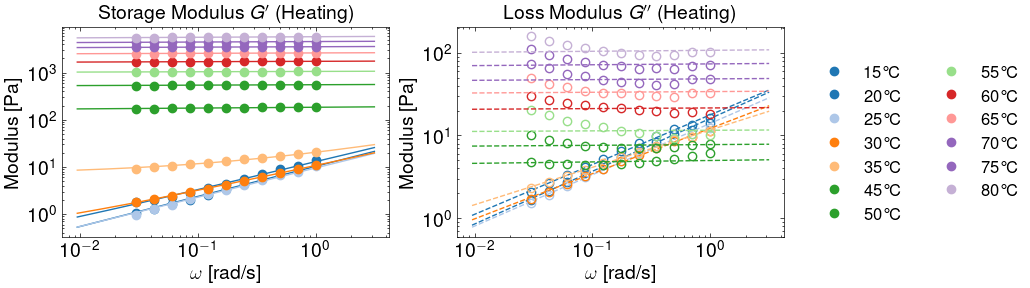

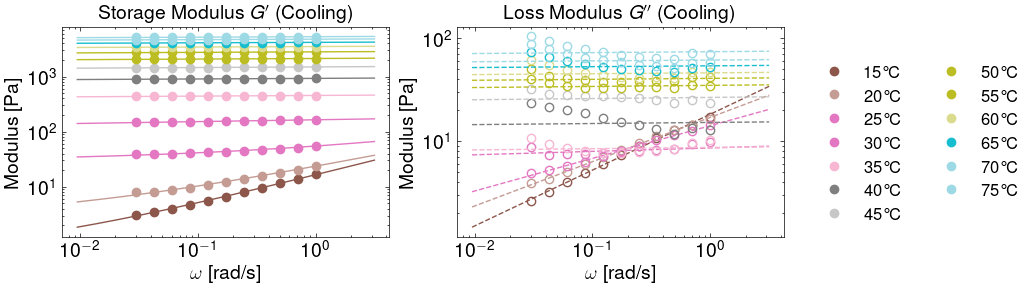

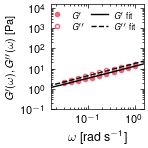

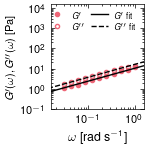

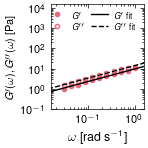

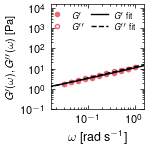

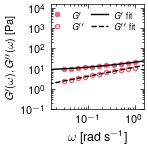

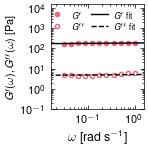

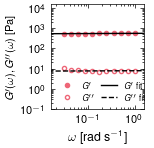

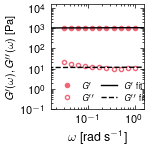

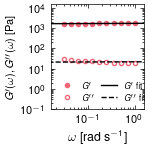

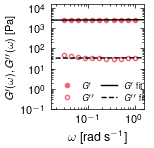

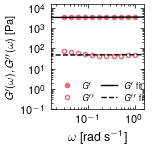

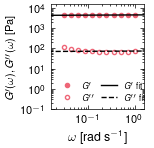

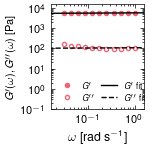

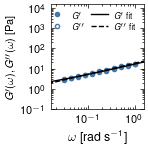

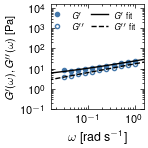

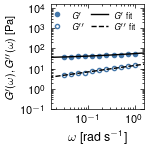

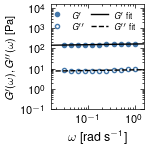

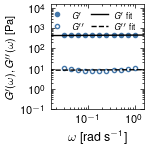

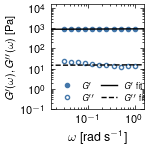

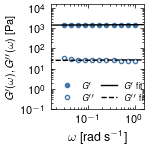

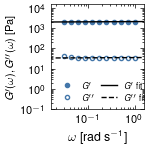

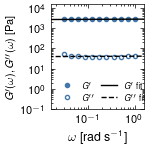

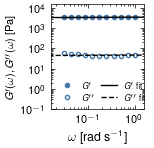

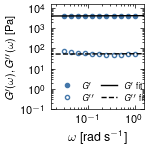

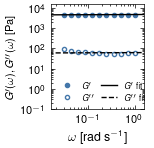

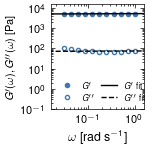

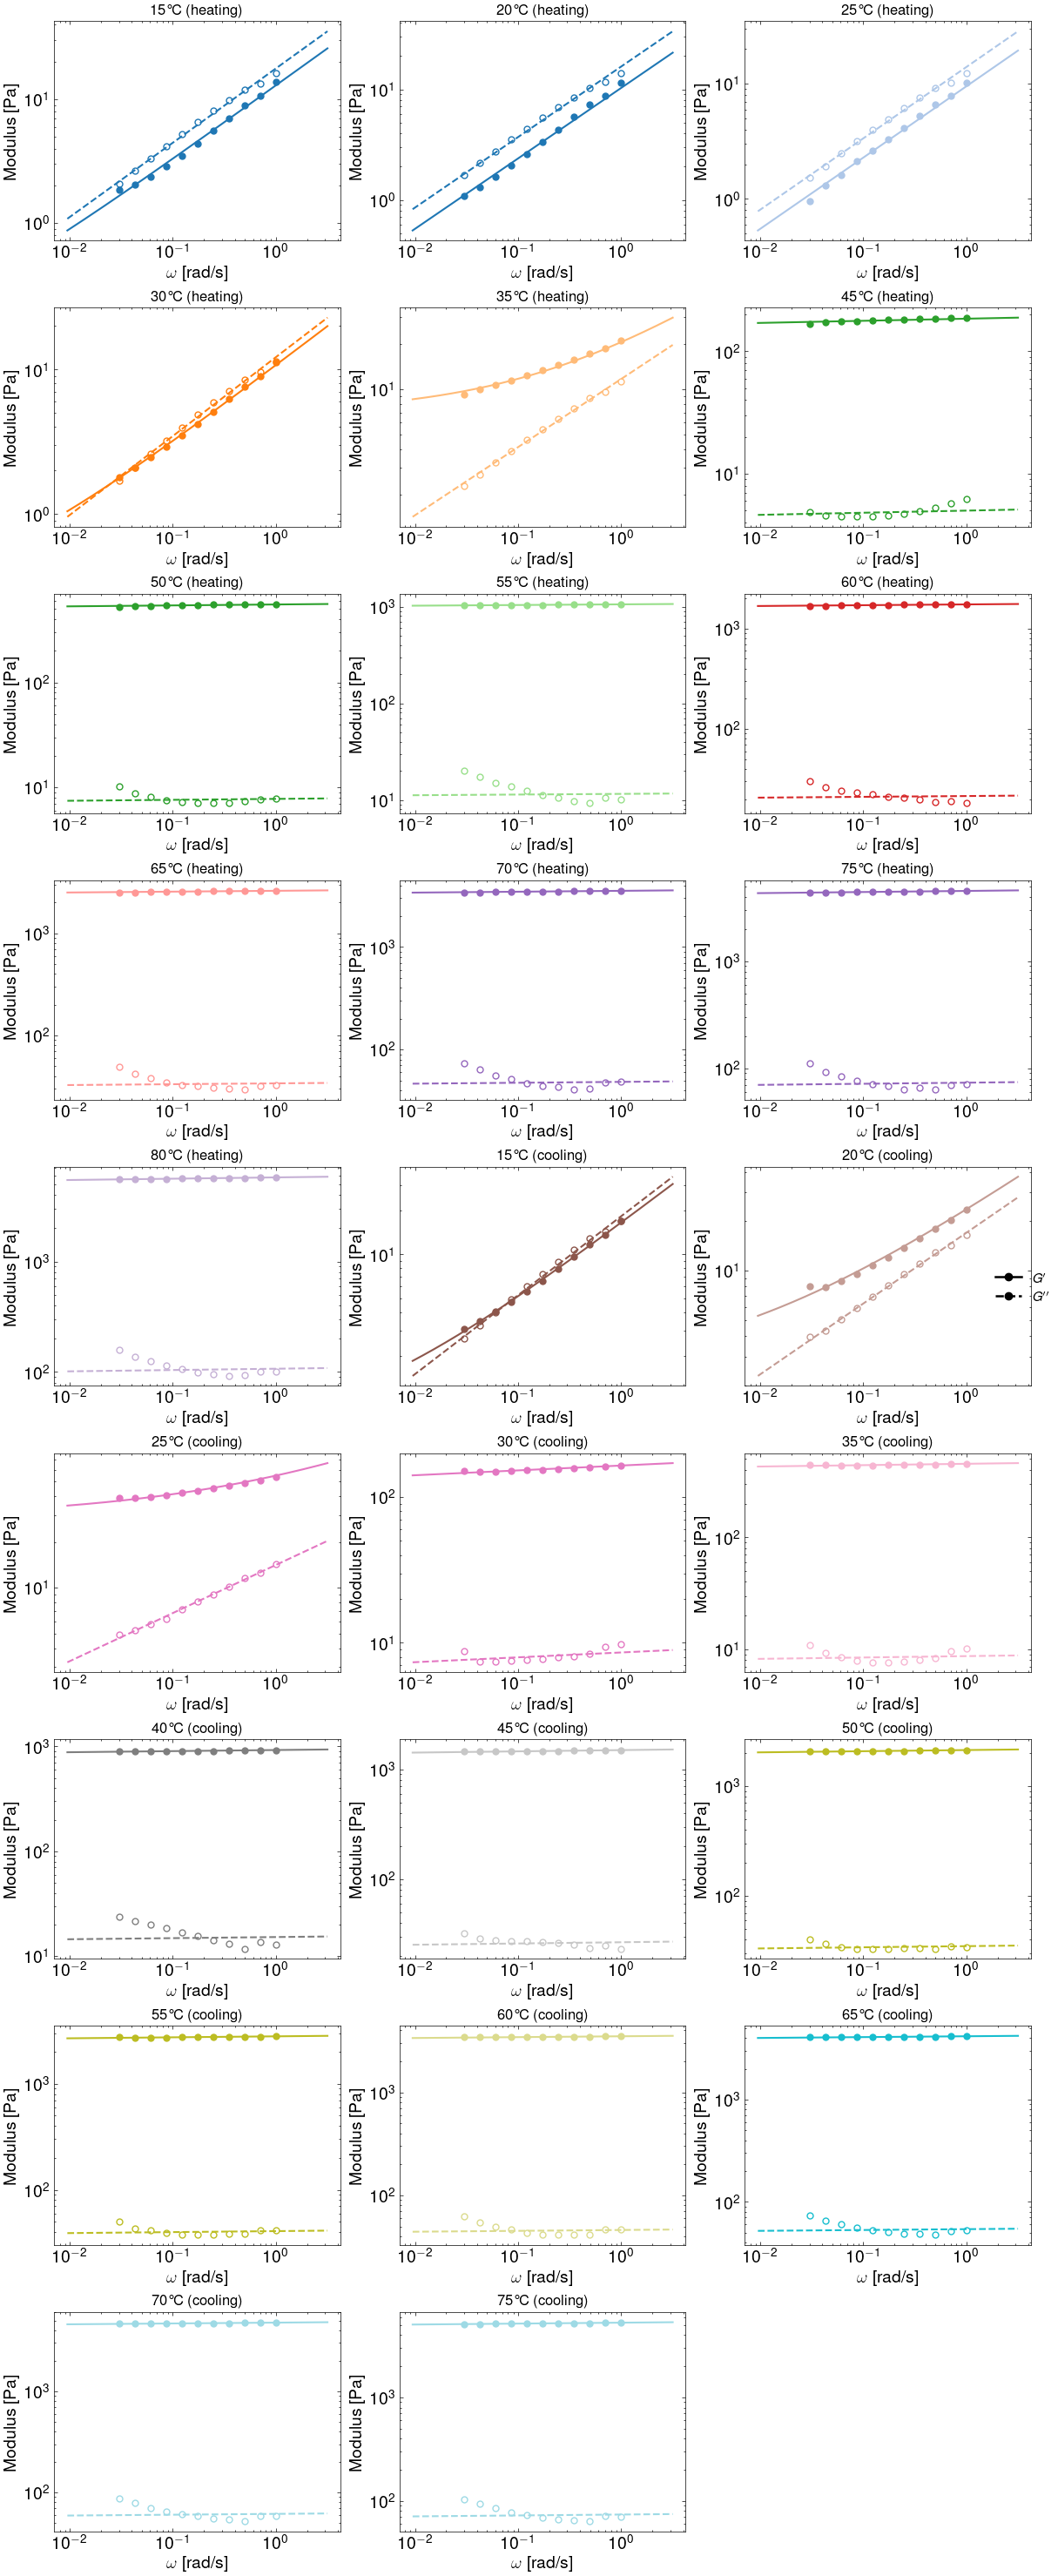

Heating Parameters: {15.0: {'G_p': 0.08550490683026009, 'V': 21.939928237725926, 'alpha': 0.6005651296540978, 'Cost': 0.05548516367230422, 'Cost Metric': 'RSS', 'Error': None}, 20.0: {'G_p': 0.0016856345494873789, 'V': 19.06556733978818, 'alpha': 0.6372728254022954, 'Cost': 0.08224071136689098, 'Cost Metric': 'RSS', 'Error': None}, 25.0: {'G_p': 0.0015343000097387959, 'V': 16.935009037896926, 'alpha': 0.6199292568523145, 'Cost': 0.0741254514172483, 'Cost Metric': 'RSS', 'Error': None}, 30.0: {'G_p': 0.21904060508162224, 'V': 16.116781802009545, 'alpha': 0.5463775354540538, 'Cost': 0.020603194869943713, 'Cost Metric': 'RSS', 'Error': None}, 35.0: {'G_p': 6.913499371721724, 'V': 17.935446065243067, 'alpha': 0.4516628348489149, 'Cost': 0.01622273731549148, 'Cost Metric': 'RSS', 'Error': None}, 45.0: {'V': 184.47086903847898, 'alpha': 0.01722332554633887, 'Cost': 0.08548565957249757, 'Cost Metric': 'RSS', 'Error': None}, 50.0: {'V': 553.8073020082411, 'alpha': 0.00892475343052496, 'Cost': 

In [4]:
# ------------- A) Separate figures: heating-only and cooling-only (2-panel like your original) -------------

def plot_group(entries_group, title_suffix):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 3), sharex=True)
    for e in entries_group:
        ax1.loglog(e['omega'], e['Gp'], 'o', markersize=6, color=e['color'], label=e['label'])
        ax2.loglog(e['omega'], e['Gpp'], 'o', markersize=6, color=e['color'], fillstyle="none")
        ax1.plot(e['omega_pred'], e['Gp_pred'], '-', color=e['color'])
        ax2.plot(e['omega_pred'], e['Gpp_pred'], '--', color=e['color'])

    ax1.set_title(f"Storage Modulus $G'$ ({title_suffix})", fontsize=14)
    ax2.set_title(f"Loss Modulus $G''$ ({title_suffix})", fontsize=14)
    for ax in (ax1, ax2):
        ax.set_xlabel(r'$\omega$ [rad/s]', fontsize=14)
        ax.set_ylabel('Modulus [Pa]', fontsize=14)
        ax.tick_params(axis='both', labelsize=14)
        ax.grid(False)

    # Build legend from unique temperatures in this group
    labels_unique = []
    handles_unique = []
    for e in entries_group:
        if e['label'] not in labels_unique:
            labels_unique.append(e['label'])
            h = ax1.plot([], [], 'o', color=e['color'], markersize=6, label=e['label'])[0]
            handles_unique.append(h)
    fig.legend(handles_unique, labels_unique, loc='center left', bbox_to_anchor=(1.01, 0.5), ncols=2, fontsize=12)
    fig.tight_layout()
    plt.show()

heating_entries = [e for e in entries if e['process'] == 'heating']
cooling_entries = [e for e in entries if e['process'] == 'cooling']

if heating_entries:
    plot_group(heating_entries, 'Heating')
if cooling_entries:
    plot_group(cooling_entries, 'Cooling')

# ------------- B) Individual plots for each temperature (1 figure per temperature) -------------
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
for e in entries:
    plt.figure(figsize=(1.6, 1.6))

    # Choose color by process
    col = colors[1] if e['process'] == 'heating' else colors[0]
    
    # Data (use plt.plot; set log scales on axes)
    # G' data (filled circles)
    plt.plot(e['omega'], (e['Gp']), linestyle='none', marker='o',
             markersize=3, color=col, label='$G^{\prime}$')
    # G'' data (empty circles)
    plt.plot((e['omega']), (e['Gpp']), linestyle='none', marker='o',
             markersize=3, color=col, mfc='none', label='$G^{\prime \prime}$')

    # Fits
    plt.plot((e['omega_pred']), (e['Gp_pred']), '-', color="k", lw=1.0, label=r"$G^{\prime}$ fit")
    plt.plot((e['omega_pred']), (e['Gpp_pred']), '--', color="k", lw=1.0, label=r"$G^{\prime \prime}$ fit")

    # Labels
    plt.xlim(10**-1.8, 10**0.2)
    plt.ylim(10**-1, 10**4.2)
    plt.xscale('log')
    plt.yscale('log')
    plt.tick_params(axis='y', which='both', direction='in')
    plt.tick_params(axis='x', which='both', direction='in')
    plt.xticks(fontsize=8)
    plt.yticks(fontsize=8)
    plt.xlabel('$\omega~\mathrm{[rad~s^{-1}]}$', fontsize=9)
    plt.ylabel('$G^{\prime}(\omega), G^{\prime \prime}(\omega)~\mathrm{[Pa]}$', fontsize=8)

    # Legend
    plt.legend(fontsize=6, ncol=2, columnspacing=0.7, frameon=False)

    plt.tight_layout()
    temp_int = int(e['T'])
    process_str = str(e['process']).lower()
    plt.savefig(f'../figures/main/saos_fractional_rheology/1.75/fig_saos_fittings_1.75_{process_str}_{temp_int}.pdf')
    plt.show()

# ------------- C) Subplot grid with all results (one axes per temperature) -------------

n = len(entries)
if n > 0:
    # Choose grid shape (e.g., 3 columns)
    ncols = 3
    nrows = int(np.ceil(n / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(4*ncols, 3.3*nrows), sharex=False, sharey=False)
    axes = np.atleast_2d(axes)

    for k, e in enumerate(entries):
        r, c = divmod(k, ncols)
        ax = axes[r, c]
        # Data
        ax.loglog(e['omega'], e['Gp'], 'o', color=e['color'], markersize=5, label=r"$G'$ data")
        ax.loglog(e['omega'], e['Gpp'], 'o', color=e['color'], markersize=5, fillstyle="none", label=r"$G''$ data")
        # Fits
        ax.plot(e['omega_pred'], e['Gp_pred'], '-', color=e['color'], lw=1.5, label=r"$G'$ fit")
        ax.plot(e['omega_pred'], e['Gpp_pred'], '--', color=e['color'], lw=1.5, label=r"$G''$ fit")

        ax.set_title(f"{int(e['T'])}°C ({e['process']})", fontsize=12)
        ax.set_xlabel(r'$\omega$ [rad/s]', fontsize=14)
        ax.set_ylabel('Modulus [Pa]', fontsize=14)
        ax.tick_params(axis='both', labelsize=14)
        ax.grid(False)

    # Hide any unused subplots
    for k in range(n, nrows*ncols):
        r, c = divmod(k, ncols)
        fig.delaxes(axes[r, c])

    # Single legend outside (optional): comment out if too crowded
    # Build unique legend entries
    Lh, Ll = [], []
    for style, lbl in [(('o', '-'), r"$G'$"), (('o', '--'), r"$G''$")]:
        # Proxy handles
        h = plt.Line2D([], [], color='k', marker=style[0], linestyle=style[1], lw=1.8, markersize=6)
        Lh.append(h); Ll.append(lbl)
    fig.legend(Lh, Ll, loc='center right', bbox_to_anchor=(1.02, 0.5), frameon=False, fontsize=11)

    fig.tight_layout()
    plt.show()

# Print fitted parameters for analysis
print("Heating Parameters:", fitted_parameters_heating)
print("Cooling Parameters:", fitted_parameters_cooling)


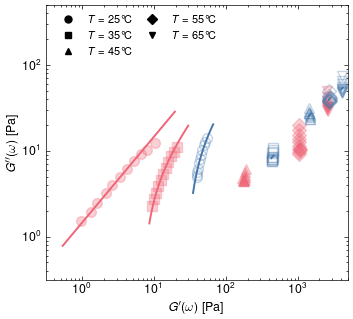

In [5]:
import numpy as np
import matplotlib.pyplot as plt

# One figure: log G'' (y) vs log G' (x) for selected temperatures and both processes
selected_temps = {25, 35, 45, 55, 65}
markers_by_T = {25: 'o', 35: 's', 45: '^', 55: 'D', 65: 'v'}  # marker per temperature
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']

plt.figure(figsize=(3.640625, 3.3))

for e in entries:
    T_int = int(e['T'])
    if T_int not in selected_temps:
        continue
    proc = e['process']
    col = colors[1] if proc == 'heating' else colors[0]
    mk = markers_by_T.get(T_int, 'o')

    # Data: x = log10(G'), y = log10(G'')
    x_data = (e['Gp'])
    y_data = (e['Gpp'])

    # Plot data markers (empty face for cooling for extra contrast)
    if proc == 'heating':
        plt.plot(x_data, y_data, linestyle='none', marker=mk, markersize=7,
                 color=col, alpha=0.3, label=f"{T_int}°C (data)" if False else None)
    else:
        plt.plot(x_data, y_data, linestyle='none', marker=mk, markersize=7,
                 color=col, alpha=0.3, mfc='none', label=f"{T_int}°C (data)" if False else None)

    # Fit curve: parametric in omega_pred
    idx = np.argsort(e['omega_pred'])
    x_fit = (e['Gp_pred'])[idx]
    y_fit = (e['Gpp_pred'])[idx]
    plt.plot(x_fit, y_fit, '-', color=col, lw=1.4)

# Axes, style
plt.xscale('log')
plt.yscale('log')
plt.xlabel(r'$G^{\prime}(\omega)\ \mathrm{[Pa]}$', fontsize=9)
plt.ylabel(r'$G^{\prime\prime}(\omega)\ \mathrm{[Pa]}$', fontsize=9)
plt.xlim(10**-0.5, 10**3.7)
plt.ylim(10**-0.5, 10**2.7)
plt.tick_params(axis='both', which='both', direction='in', labelsize=9)
plt.grid(False)

# Build two legends: process (colors) and temperature (markers)
from matplotlib.lines import Line2D

process_handles = [
    Line2D([0], [0], color=colors[1], lw=1.8, label='heating'),
    Line2D([0], [0], color=colors[0], lw=1.8, label='cooling'),
]
temp_handles = []
for T in sorted(selected_temps):
    mk = markers_by_T[T]
    temp_handles.append(Line2D([0], [0], marker=mk, linestyle='none', color='k',
                               markersize=5, label=f'$T={T}$°C'))

#leg1 = plt.legend(handles=process_handles, loc='upper left', frameon=False, fontsize=11)
#plt.gca().add_artist(leg1)
plt.legend(handles=temp_handles, loc='upper left', ncols=2, columnspacing=0.7,  frameon=False, fontsize=8)

plt.tight_layout()
plt.savefig(f'../figures/main/saos_fractional_rheology/1.75/fig_saos_colecole_1.75.pdf')
# Show the plot
plt.show()


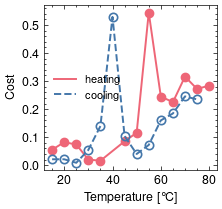

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import os

# Extract and sort by temperature
def extract_temp_cost(params_dict):
    temps = []
    costs = []
    for T, p in params_dict.items():
        # T might be float or str; ensure numeric temperature
        try:
            t_val = float(T)
        except Exception:
            continue
        c_val = p.get('Cost', np.nan)
        if np.isfinite(c_val):
            temps.append(t_val)
            costs.append(float(c_val))
    if temps:
        temps = np.array(temps); costs = np.array(costs)
        idx = np.argsort(temps)
        temps, costs = temps[idx], costs[idx]
    else:
        temps, costs = np.array([]), np.array([])
    return temps, costs

Th, Ch = extract_temp_cost(fitted_parameters_heating)
Tc, Cc = extract_temp_cost(fitted_parameters_cooling)

# Plot
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
plt.figure(figsize=(2.33, 2.2))

if Th.size:
    plt.plot(Th, Ch, '-', color=colors[1], lw=1.4, label='heating')
    plt.plot(Th, Ch, 'o', color=colors[1], ms=6)
if Tc.size:
    plt.plot(Tc, Cc, '--', color=colors[0], lw=1.4, label='cooling')
    plt.plot(Tc, Cc, 'o', mfc='none', mec=colors[0], mew=1.2, color=colors[0], ms=6)

# Style
plt.xlabel('Temperature [°C]', fontsize=9)
plt.ylabel('Cost', fontsize=9)
plt.tick_params(axis='y', which='both', direction='in')
plt.tick_params(axis='x', which='both', direction='in')
plt.xticks(fontsize=9)
plt.yticks(fontsize=9)
plt.legend(fontsize=8, frameon=False, loc='best')

plt.tight_layout()

# Define concentration
concentration_str = "1.75"  # adjust if needed

# --- Save data for heating ---
if Th.size:
    df_heating = pd.DataFrame({"Temperature_C": Th, "Cost": Ch})
    out_csv_heating = f"../results/1.75/cost_heating_concentration_{concentration_str}.csv"
    os.makedirs(os.path.dirname(out_csv_heating), exist_ok=True)
    df_heating.to_csv(out_csv_heating, index=False)

# --- Save data for cooling ---
if Tc.size:
    df_cooling = pd.DataFrame({"Temperature_C": Tc, "Cost": Cc})
    out_csv_cooling = f"../results/1.75/cost_data_cooling_concentration_{concentration_str}.csv"
    os.makedirs(os.path.dirname(out_csv_cooling), exist_ok=True)
    df_cooling.to_csv(out_csv_cooling, index=False)

# --- Save figure ---
out_path = f"../figures/main/saos_fractional_rheology/{concentration_str}/fig_saos_cost_vs_temperature_concentration_{concentration_str}.pdf"
os.makedirs(os.path.dirname(out_path), exist_ok=True)
plt.savefig(out_path, dpi=600, bbox_inches='tight', pad_inches=0.1)

plt.show()

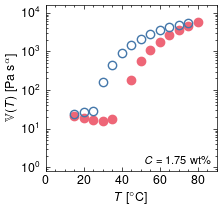

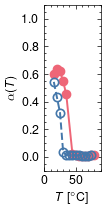

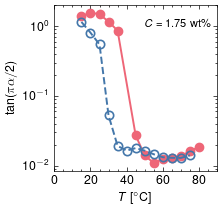

In [7]:
import numpy as np
import matplotlib.pyplot as plt
import os

# Helper: extract a parameter key vs temperature from a fitted-parameters dict
def extract_temp_key(params_dict, key):
    temps, vals = [], []
    for T, p in params_dict.items():
        try:
            t_val = float(T)
        except Exception:
            continue
        v = p.get(key, np.nan)
        if np.isfinite(v):
            temps.append(t_val)
            vals.append(float(v))
    if temps:
        temps = np.array(temps); vals = np.array(vals)
        idx = np.argsort(temps)
        temps, vals = temps[idx], vals[idx]
    else:
        temps, vals = np.array([]), np.array([])
    return temps, vals


# ---------------------------------------------------------------------
# Parameters
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
concentration_str = "1.75"
concentration = float(concentration_str)

# Define base output directory
fig_dir = f"../figures/main/saos_fractional_rheology/{concentration_str}"
os.makedirs(fig_dir, exist_ok=True)

# ---------------------------------------------------------------------
# --------- V vs Temperature ---------
Th, Vh = extract_temp_key(fitted_parameters_heating, 'V')
Tc, Vc = extract_temp_key(fitted_parameters_cooling, 'V')

plt.figure(figsize=(2.33, 2.2))
if Th.size:
    plt.plot(Th, Vh, 'o', ms=6, color=colors[1], lw=1.4, label='heating')
if Tc.size:
    plt.plot(Tc, Vc, 'o', ms=6, fillstyle="none", color=colors[0], lw=1.4, label='cooling')

plt.yscale('log')
plt.xlim(0, 90)
plt.ylim(10**-0.08, 10**4.2)
plt.tick_params(axis='y', which='both', direction='in')
plt.tick_params(axis='x', which='both', direction='in')
plt.xticks(fontsize=9)
plt.yticks(fontsize=9)
plt.xlabel('$T~\\mathrm{[^{\\circ}C]}$', fontsize=9)
plt.ylabel(r'$\mathbb{V}(T)~[\mathrm{Pa~s}^\alpha]$', fontsize=9)
plt.text(52, 1.2, f'$C=$ {concentration:.2f} wt\\%', fontsize=8)
plt.tight_layout()

out_V = os.path.join(fig_dir, f"fig_V_vs_temperature_concentration_{concentration_str}.pdf")
plt.savefig(out_V, dpi=1200, bbox_inches='tight', pad_inches=0.1)
plt.show()


# ---------------------------------------------------------------------
# --------- alpha vs Temperature ---------
Th, Ah = extract_temp_key(fitted_parameters_heating, 'alpha')
Tc, Ac = extract_temp_key(fitted_parameters_cooling, 'alpha')

plt.figure(figsize=(1.165, 2.2))
if Th.size:
    plt.plot(Th, Ah, '-', color=colors[1], lw=1.4, label='heating')
    plt.plot(Th, Ah, 'o', color=colors[1], ms=6)
if Tc.size:
    plt.plot(Tc, Ac, '--', color=colors[0], lw=1.4, label='cooling')
    plt.plot(Tc, Ac, 'o', mfc='none', mec=colors[0], mew=1.2, color=colors[0], ms=6)

plt.xlim(0, 90)
plt.ylim(-0.1, 1.1)
plt.tick_params(axis='y', which='both', direction='in')
plt.tick_params(axis='x', which='both', direction='in')
plt.xticks(fontsize=9)
plt.yticks(fontsize=9)
plt.xlabel('$T~\\mathrm{[^{\\circ}C]}$', fontsize=9)
plt.ylabel('$\\alpha(T)$', fontsize=9)
plt.tight_layout()

out_alpha = os.path.join(fig_dir, f"fig_alpha_vs_temperature_concentration_{concentration_str}.pdf")
plt.savefig(out_alpha, dpi=1200, bbox_inches='tight', pad_inches=0.1)
plt.show()


# ---------------------------------------------------------------------
# --------- tan(delta) vs Temperature ---------
plt.figure(figsize=(2.33, 2.2))
if Th.size:
    plt.plot(Th, np.tan(np.pi * Ah * 0.5), '-', color=colors[1], lw=1.4, label='heating')
    plt.plot(Th, np.tan(np.pi * Ah * 0.5), 'o', color=colors[1], ms=6)
if Tc.size:
    plt.plot(Tc, np.tan(np.pi * Ac * 0.5), '--', color=colors[0], lw=1.4, label='cooling')
    plt.plot(Tc, np.tan(np.pi * Ac * 0.5), 'o', mfc='none', mec=colors[0], mew=1.2, color=colors[0], ms=6)

plt.yscale('log')
plt.tick_params(axis='y', which='both', direction='in')
plt.tick_params(axis='x', which='both', direction='in')
plt.xticks(fontsize=9)
plt.yticks(fontsize=9)
plt.xlabel('$T~\\mathrm{[^{\\circ}C]}$', fontsize=9)
plt.ylabel('$\\tan(\\pi \\alpha / 2)$', fontsize=9)
plt.xlim(0, 90)
plt.text(50, 0.95, f'$C=$ {concentration:.2f} wt\\%', fontsize=8)
plt.tight_layout()

out_tan = os.path.join(fig_dir, f"fig_tan_alpha_vs_temperature_concentration_{concentration_str}.pdf")
plt.savefig(out_tan, dpi=1200, bbox_inches='tight', pad_inches=0.1)
plt.show()


/tmp/ipykernel_41261/3461118715.py:59: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


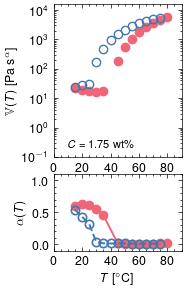

In [15]:
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

# Extract data 
Th, Vh = extract_temp_key(fitted_parameters_heating, 'V')
Tc, Vc = extract_temp_key(fitted_parameters_cooling, 'V')
Th, Ah = extract_temp_key(fitted_parameters_heating, 'alpha')
Tc, Ac = extract_temp_key(fitted_parameters_cooling, 'alpha')

# Create figure with GridSpec to make top subplot bigger
fig = plt.figure(figsize=(1.65, 3.2))
gs = GridSpec(2, 1, height_ratios=[2, 1], hspace=0.15)  # top subplot twice as tall

ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[1, 0], sharex=ax1)

# ------------------- V vs Temperature -------------------
if Th.size:
    ax1.plot(Th, Vh, 'o', ms=6, color=colors[1], lw=1.4, label='heating')
if Tc.size:
    ax1.plot(Tc, Vc, 'o', ms=6, fillstyle="none", color=colors[0], lw=1.4, label='cooling')

# Define more x-ticks (every 5 degrees)
xticks = np.arange(0, 91, 20)  # from 0 to 90 with step 5

# Apply to bottom subplot (shared x-axis)
ax2.set_xticks(xticks)
ax2.set_xticklabels([f'{x}' for x in xticks], fontsize=9)

# Optional: also show minor ticks on top subplot
ax1.set_xticks(xticks)
ax1.set_xticklabels([f'{x}' for x in xticks], fontsize=9)

ax1.set_yscale('log')
ax1.set_xlim(0, 90)
ax1.set_ylim(10**-0.08, 10**4.2)
ax1.tick_params(axis='y', which='both', direction='in', labelsize=9)
ax1.tick_params(axis='x', which='both', direction='in', labelbottom=True, labelsize=9)  # hide x labels
ax1.set_yticks([1e-1, 1, 1e1, 1e2, 1e3, 1e4])
ax1.set_ylabel(r'$\mathbb{V}(T)~[\mathrm{Pa~s}^\alpha]$', fontsize=9)
ax1.text(10, 2E-1, f'$C=$ {concentration:.2f} wt\%', fontsize=8)
#ax1.legend(fontsize=7, loc="lower right")

# ------------------- alpha vs Temperature -------------------
if Th.size:
    ax2.plot(Th, Ah, '-', color=colors[1], lw=1.4, label='heating')
    ax2.plot(Th, Ah, 'o', color=colors[1], ms=6)
if Tc.size:
    ax2.plot(Tc, Ac, '--', color=colors[0], lw=1.4, label='cooling')
    ax2.plot(Tc, Ac, 'o', mfc='none', mec=colors[0], mew=1.2, color=colors[0], ms=6)

ax2.set_xlim(0, 90)
ax2.set_ylim(-0.1, 1.1)
ax2.tick_params(axis='y', which='both', direction='in', labelsize=9)
ax2.tick_params(axis='x', which='both', direction='in', labelsize=9)
ax2.set_xlabel('$T~\mathrm{[^{\circ}C]}$', fontsize=9)
ax2.set_ylabel('$\\alpha(T)$', fontsize=9)

plt.tight_layout()

# Save figure
out_combined = os.path.join(fig_dir, f"fig_V_alpha_vs_temperature_concentration_{concentration_str}.pdf")
plt.savefig(out_combined, dpi=1200, bbox_inches='tight', pad_inches=0.1)
plt.show()


In [8]:
import pandas as pd
import numpy as np
import os

# Prepare output directory
out_dir = "../results/1.75"
os.makedirs(out_dir, exist_ok=True)

# Save heating + cooling data
df_heating = pd.DataFrame({
    "Temperature_H": Th,
    "Alpha_H": Ah,
    "Tan_delta_H": np.tan(np.pi * Ah * 0.5),
    "V_H": Vh,
    "Temperature_C": Tc,
    "Alpha_C": Ac,
    "Tan_delta_C": np.tan(np.pi * Ac * 0.5),
    "V_C": Vc,
})

# Create a filename using the concentration
concentration_str = f"{concentration:.2f}".replace(".", "_")
csv_file = os.path.join(out_dir, f"tan_alpha_heating_cooling_{concentration_str}.csv")

# Save to CSV
df_heating.to_csv(csv_file, index=False)
print(f"Heating data saved to {csv_file}")


Heating data saved to ../results/1.75/tan_alpha_heating_cooling_1_75.csv


[210.  147.9 104.1  73.3  51.6  36.3  25.6  18.1  12.6   9.    6.3]


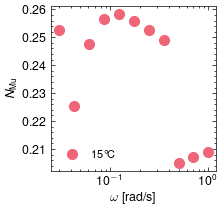

[210.  147.9 104.1  73.3  51.6  36.3  25.6  18.1  12.6   9.    6.3]


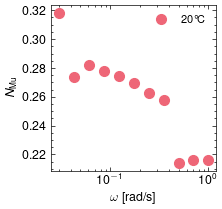

[210.  147.9 104.1  73.3  51.6  36.3  25.6  18.1  12.6   9.    6.3]


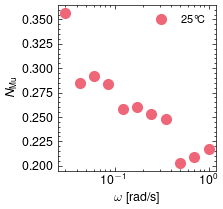

[210.  147.9 104.1  73.3  51.6  36.3  25.6  18.1  12.6   9.    6.3]


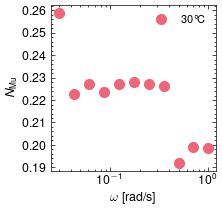

[210.  147.9 104.1  73.3  51.6  36.3  25.6  18.1  12.6   9.    6.3]


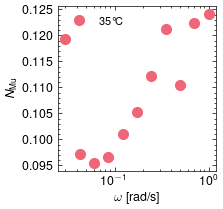

[210.  147.9 104.1  73.3  51.6  36.3  25.6  18.1  12.6   9.    6.3]


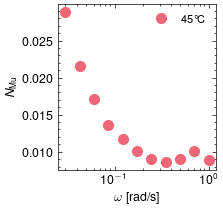

[210.  147.9 104.1  73.3  51.6  36.3  25.6  18.1  12.6   9.    6.3]


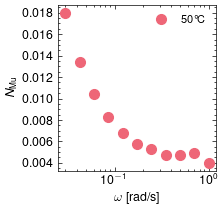

[210.  147.9 104.1  73.3  51.6  36.3  25.6  18.1  12.6   9.    6.3]


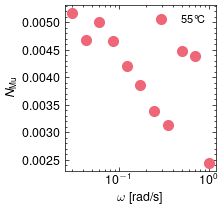

[210.  147.9 104.1  73.3  51.6  36.3  25.6  18.1  12.6   9.    6.3]


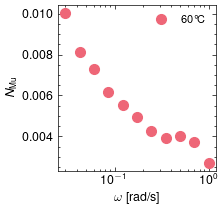

[210.  147.9 104.1  73.3  51.6  36.3  25.6  18.1  12.6   9.    6.3]


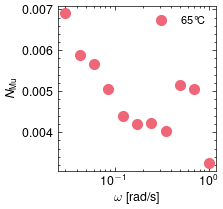

[210.  147.9 104.1  73.3  51.6  36.3  25.6  18.1  12.6   9.    6.3]


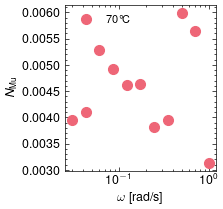

[210.  147.9 104.1  73.3  51.6  36.3  25.6  18.1  12.6   9.    6.3]


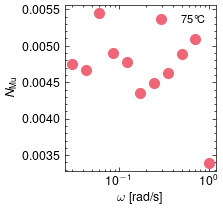

[210.  147.9 104.1  73.3  51.6  36.3  25.6  18.1  12.6   9.    6.3]


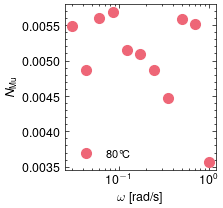

[210.  147.9 104.1  73.3  51.6  36.3  25.6  18.1  12.6   9.    6.3]


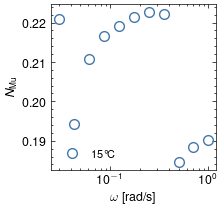

[210.  147.9 104.1  73.3  51.6  36.3  25.6  18.1  12.6   9.    6.3]


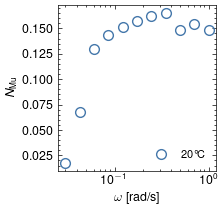

[210.  147.9 104.1  73.3  51.6  36.3  25.6  18.1  12.6   9.    6.3]


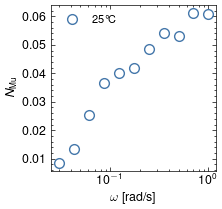

[210.  147.9 104.1  73.3  51.6  36.3  25.6  18.1  12.6   9.    6.3]


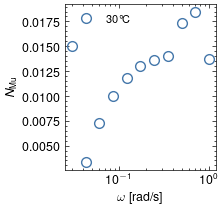

[210.  147.9 104.1  73.3  51.6  36.3  25.6  18.1  12.6   9.    6.3]


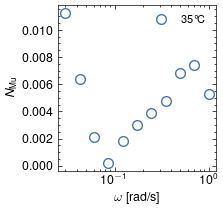

[210.  147.9 104.1  73.3  51.6  36.3  25.6  18.1  12.6   9.    6.3]


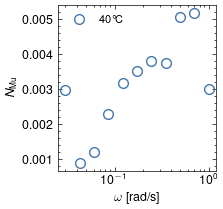

[210.  147.9 104.1  73.3  51.6  36.3  25.6  18.1  12.6   9.    6.3]


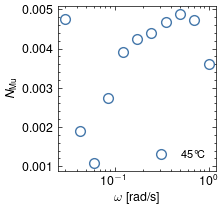

[210.  147.9 104.1  73.3  51.6  36.3  25.6  18.1  12.6   9.    6.3]


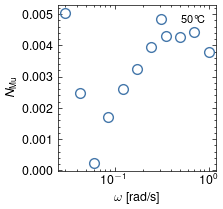

[210.  147.9 104.1  73.3  51.6  36.3  25.6  18.1  12.6   9.    6.3]


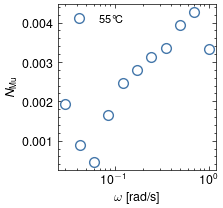

[210.  147.9 104.1  73.3  51.6  36.3  25.6  18.1  12.6   9.    6.3]


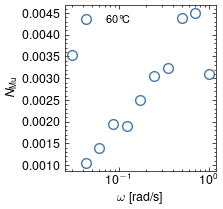

[210.  147.9 104.1  73.3  51.6  36.3  25.6  18.1  12.6   9.    6.3]


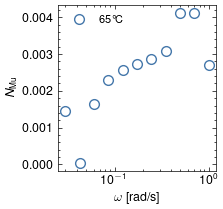

[210.  147.9 104.1  73.3  51.6  36.3  25.6  18.1  12.6   9.    6.3]


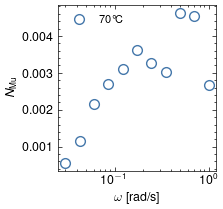

[210.  147.9 104.1  73.3  51.6  36.3  25.6  18.1  12.6   9.    6.3]


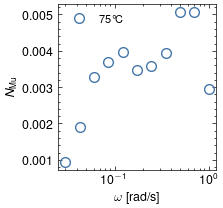

In [9]:
import numpy as np
import matplotlib.pyplot as plt

def central_difference(y, x):
    dy_dt = np.zeros_like(y)
    n = len(y)
    dy_dt[0]  = (y[1] - y[0]) / (x[1] - x[0])          # forward
    for i in range(1, n-1):                             # central
        dy_dt[i] = (y[i+1] - y[i-1]) / (x[i+1] - x[i-1])
    dy_dt[-1] = (y[-1] - y[-2]) / (x[-1] - x[-2])      # backward
    return dy_dt

colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
max_N_mu_heating = []
max_N_mu_cooling = []

for i in range(len(omega_log_list)):
    temp = temp_list[i]

    # Back to linear
    Gp = np.exp(G_prime_log_list[i])
    Gpp = np.exp(G_double_prime_log_list[i])
    omega = np.exp(omega_log_list[i])

    # If you already have the "Time" column in linear seconds per sweep, use it directly:
    # time = time_list[i]  # replace with your actual time column in seconds
    # If your code stores log-time:
    time = np.exp(t_log_list[i])

    if len(time) < 2 or np.any(~np.isfinite(time)) or np.any(np.diff(time) < 0):
        print(f"Skipping index {i} due to insufficient or non-monotonic time data.")
        continue

    # G* magnitude and its time derivative (ln-space)
    Gabs = np.sqrt(Gp**2 + Gpp**2)
    dlnGdt = central_difference(np.log(Gabs), time)  # 1/s

    # Observation time per point from the "Time" column:
    # first point uses absolute time, rest are differences
    T_obs = np.empty_like(time)
    T_obs[0] = time[0]
    T_obs[1:] = time[1:] - time[:-1]
    # guard against non-positive durations
    T_obs = np.where(T_obs > 0, T_obs, np.nan)
    print(T_obs)

    # Mutation number per point: N_mu = T_obs / t_mu = T_obs * |d ln G* / dt|
    N_mu = T_obs * np.abs(dlnGdt)

    # Store max per sweep
    Nmu_max = np.nanmax(N_mu)
    if process_list[i] == 'heating':
        max_N_mu_heating.append((temp, Nmu_max))
        col = colors[1]
        mfc = None
    else:
        max_N_mu_cooling.append((temp, Nmu_max))
        col = colors[0]
        mfc = 'none'

    # Plot per temperature
    plt.figure(figsize=(2.33, 2.2))
    plt.semilogx(omega, N_mu, linestyle='none', marker='o',
                 color=col, markersize=7, mfc=mfc, label=f"{int(temp)}°C")

    plt.xlabel(r'$\omega$ [rad/s]', fontsize=9)
    plt.ylabel(r'$N_{\text{Mu}}$', fontsize=9)
    plt.tick_params(axis='y', which='both', direction='in')
    plt.tick_params(axis='x', which='both', direction='in')
    plt.xticks(fontsize=9)
    plt.yticks(fontsize=9)
    plt.legend(fontsize=8, frameon=False, loc='best')
    plt.tight_layout()
    plt.show()

In [10]:
import csv
import os

# Ensure results directory exists
out_dir = "../results/1.75"
os.makedirs(out_dir, exist_ok=True)

# Assuming the concentration value is 1.75 for all entries
concentration = 1.75

# Extract temperatures and V values for heating
heating_temps = sorted(fitted_parameters_heating.keys())
heating_V_values = [fitted_parameters_heating[temp]['V'] for temp in heating_temps]

# Extract temperatures and V values for cooling
cooling_temps = sorted(fitted_parameters_cooling.keys())
cooling_V_values = [fitted_parameters_cooling[temp]['V'] for temp in cooling_temps]

# Format concentration as a string suitable for file naming
concentration_str = f"{concentration:.2f}".replace('.', '_')

# --- Export heating data ---
heating_csv_file_path = os.path.join(out_dir, f"fitted_parameters_heating_conc_{concentration_str}.csv")
with open(heating_csv_file_path, mode='w', newline='') as file:
    writer = csv.DictWriter(file, fieldnames=['Temperature', 'V', 'Concentration', 'Process'])
    writer.writeheader()
    for temp, V in zip(heating_temps, heating_V_values):
        writer.writerow({'Temperature': temp, 'V': V, 'Concentration': concentration, 'Process': 'heating'})

print(f'Heating data saved to {heating_csv_file_path}')

# --- Export cooling data ---
cooling_csv_file_path = os.path.join(out_dir, f"fitted_parameters_cooling_conc_{concentration_str}.csv")
with open(cooling_csv_file_path, mode='w', newline='') as file:
    writer = csv.DictWriter(file, fieldnames=['Temperature', 'V', 'Concentration', 'Process'])
    writer.writeheader()
    for temp, V in zip(cooling_temps, cooling_V_values):
        writer.writerow({'Temperature': temp, 'V': V, 'Concentration': concentration, 'Process': 'cooling'})

print(f'Cooling data saved to {cooling_csv_file_path}')


Heating data saved to ../results/1.75/fitted_parameters_heating_conc_1_75.csv
Cooling data saved to ../results/1.75/fitted_parameters_cooling_conc_1_75.csv
